In [1]:
# Dataset Extraction: Gold Prices (GC=F)
# Time period: January 2010 to December 2025

import yfinance as yf
import pandas as pd

# Define ticker and date range
ticker = "GC=F"   # Gold Futures
start_date = "2010-01-01"
end_date = "2025-12-31"

# Download data
df = yf.download(ticker, start=start_date, end=end_date)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Save to CSV
file_name = "Gold_GC_F_2010_2025.csv"
df.to_csv(file_name, index=False)

# Basic verification
print("Gold dataset downloaded successfully!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Dataset shape:", df.shape)
print(df.head())


/tmp/ipython-input-389447192.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Gold dataset downloaded successfully!
Date range: 2010-01-04 00:00:00 to 2025-12-30 00:00:00
Dataset shape: (4022, 6)
Price        Date        Close         High          Low         Open Volume
Ticker                    GC=F         GC=F         GC=F         GC=F   GC=F
0      2010-01-04  1117.699951  1122.300049  1097.099976  1117.699951    184
1      2010-01-05  1118.099976  1126.500000  1115.000000  1118.099976     53
2      2010-01-06  1135.900024  1139.199951  1120.699951  1135.900024    363
3      2010-01-07  1133.099976  1133.099976  1129.199951  1133.099976     56
4      2010-01-08  1138.199951  1138.199951  1122.699951  1138.199951     54


# Gold Futures (GC=F) – Clean + EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Load dataset
# Remove the second header row if it exists
df = pd.read_csv("Gold_GC_F_2010_2025.csv",skiprows=[1])


Data type correction

In [3]:

df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Set Date as index
df.set_index('Date', inplace=True)

In [4]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4022 entries, 2010-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4022 non-null   float64
 1   High    4022 non-null   float64
 2   Low     4022 non-null   float64
 3   Open    4022 non-null   float64
 4   Volume  4022 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.5 KB
None


In [5]:
# Check missing values

print("Missing values before cleaning:")
print(df.isna().sum())

Missing values before cleaning:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Exploratory Data Analysis

Time Series Plot (Gold Futures Closing Price)

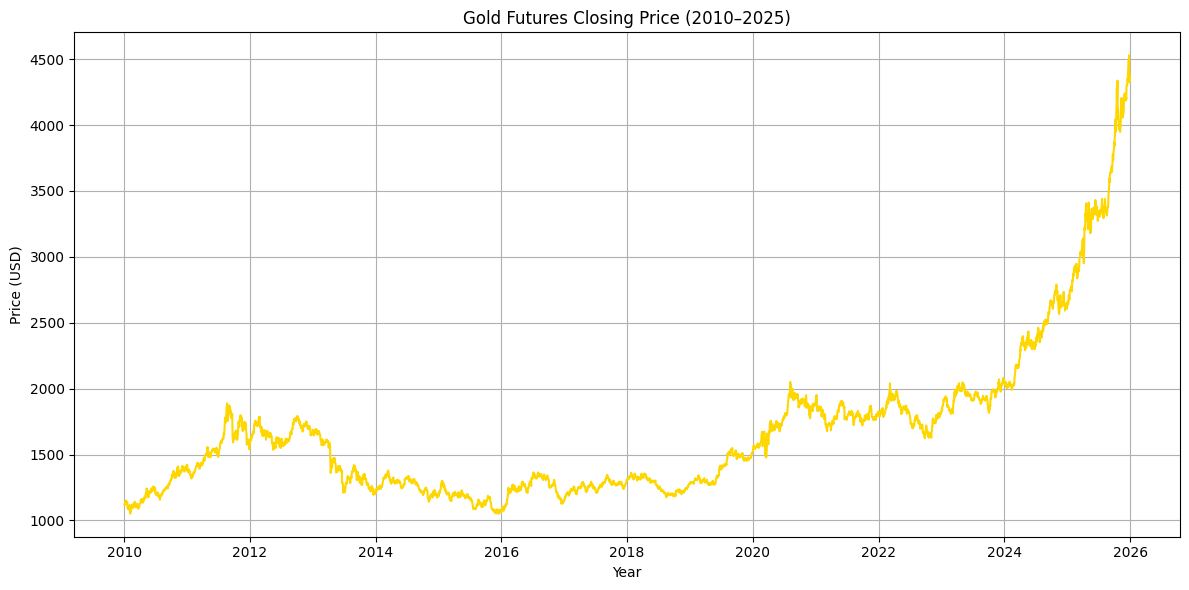

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], color='gold')
plt.title("Gold Futures Closing Price (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.grid(True)
plt.show()

Normal Distribution of Features

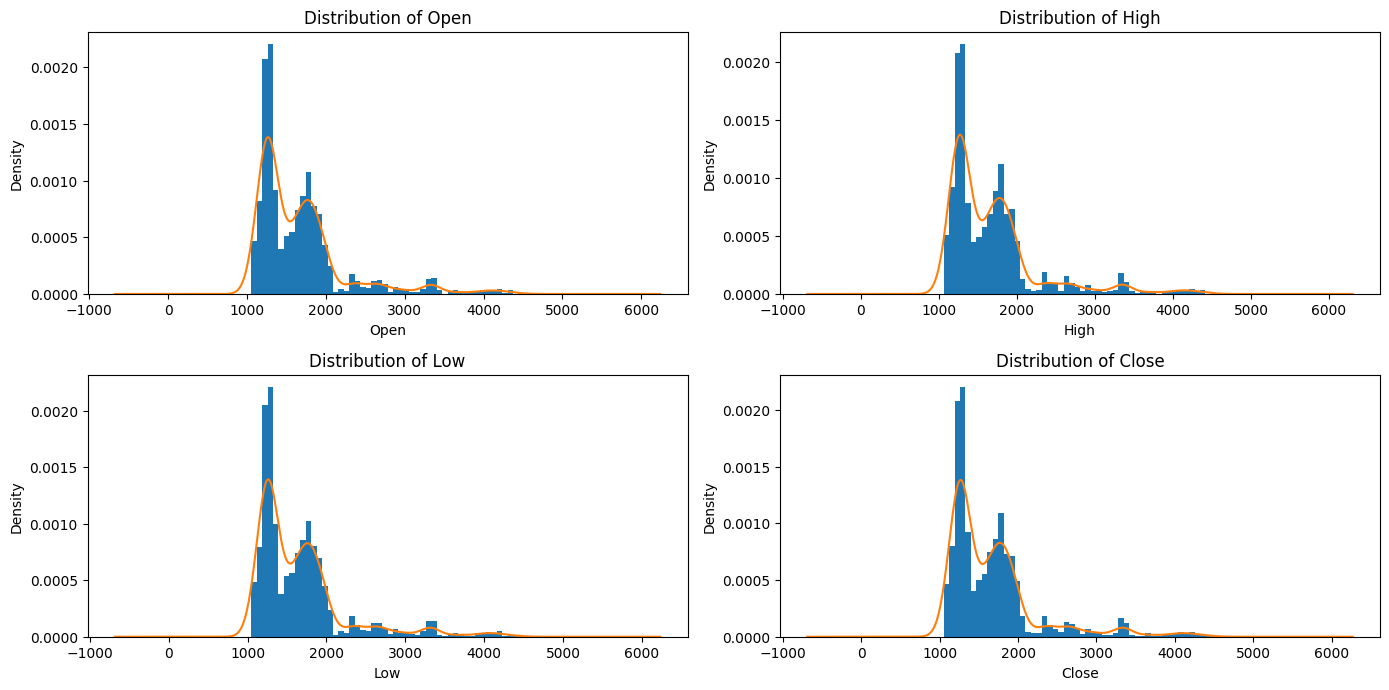

In [7]:
features = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(14,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    df[col].plot(kind='hist', bins=50, density=True)
    df[col].plot(kind='density')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


The distributions of Open, High, Low, and Close prices are right-skewed and non-normal, with multiple peaks. This reflects different market regimes over time rather than a single stable price level. The long right tail corresponds to recent years where gold prices increased sharply.

Boxplots Of Features

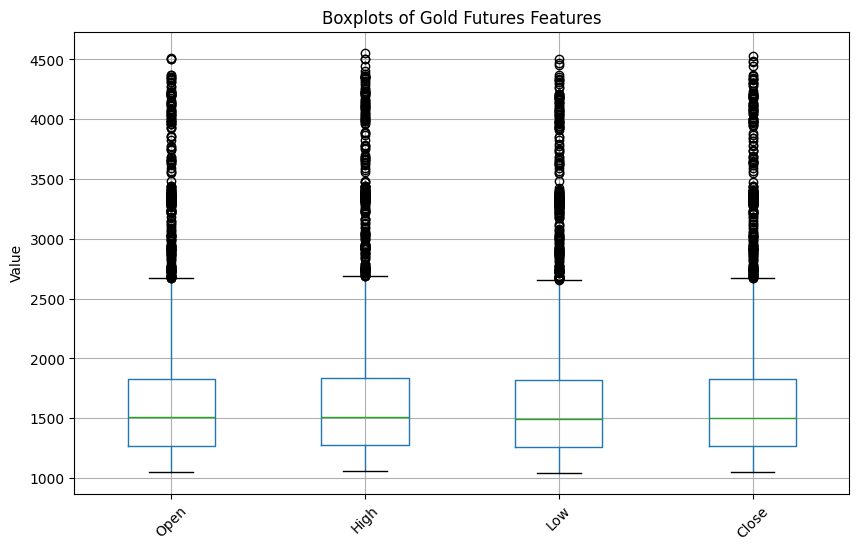

In [8]:
plt.figure(figsize=(10,6))
df[features].boxplot()
plt.title("Boxplots of Gold Futures Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


The observed outliers are not errors. They occur because:
1.   Gold prices experienced structural shifts, not random noise
2.   Major economic events caused sharp upward price movements

The boxplot outliers represent genuine extreme market conditions and were retained to preserve the true dynamics of the gold price series.



Close Price Distribution with Mean, Median & Curve

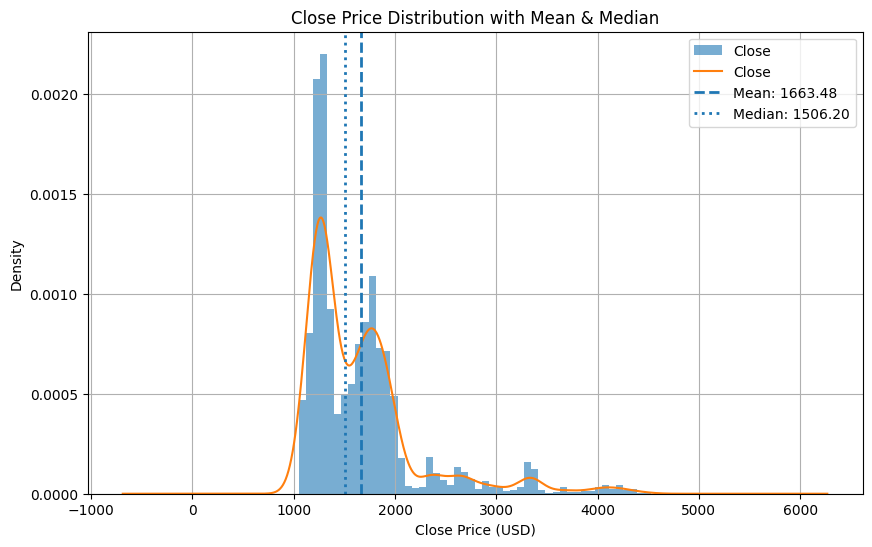

In [9]:
mean_close = df['Close'].mean()
median_close = df['Close'].median()

plt.figure(figsize=(10,6))
df['Close'].plot(kind='hist', bins=50, density=True, alpha=0.6)
df['Close'].plot(kind='density')

plt.axvline(mean_close, linestyle='--', linewidth=2, label=f"Mean: {mean_close:.2f}")
plt.axvline(median_close, linestyle=':', linewidth=2, label=f"Median: {median_close:.2f}")

plt.title("Close Price Distribution with Mean & Median")
plt.xlabel("Close Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


Observation
*   Mean > Median
*   Indicates right-skewness
*   A small number of very high prices pull the mean upward

Interpretation

The divergence between mean and median confirms the asymmetric distribution of gold prices, driven by recent price surges in the later years of the dataset.

Year-wise Mean CLOSE Price – BAR PLOT

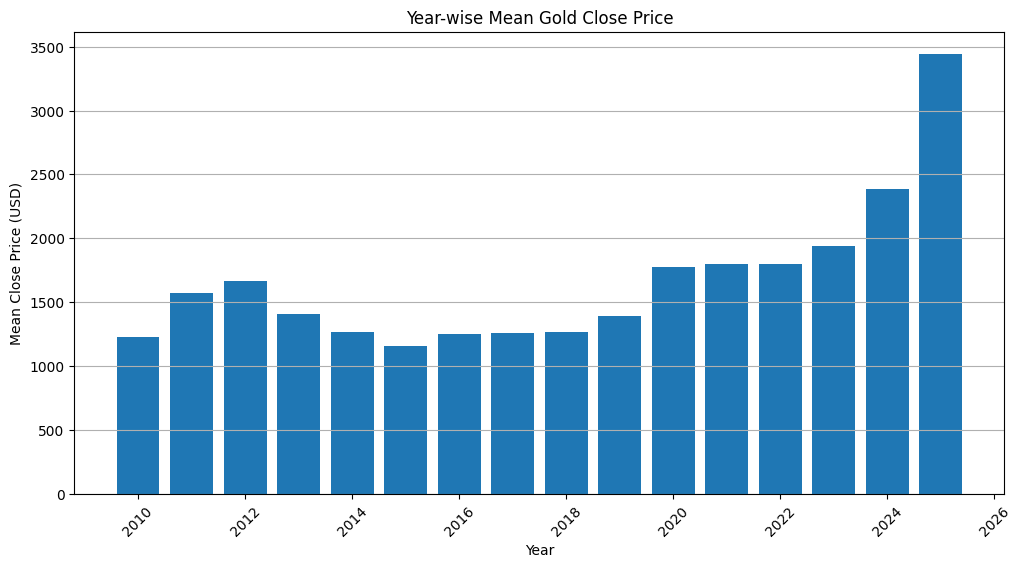

In [10]:
df['Year'] = df.index.year
yearly_mean_close = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12,6))
plt.bar(yearly_mean_close.index, yearly_mean_close.values)
plt.title("Year-wise Mean Gold Close Price")
plt.xlabel("Year")
plt.ylabel("Mean Close Price (USD)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


The bar plot shows a clear long-term upward trend in gold prices with distinct phases. Prices rise sharply during 2010–2012, decline and stabilise between 2013–2019, and then increase significantly from 2020 onwards. The strong acceleration after 2022 reflects heightened economic uncertainty, inflationary pressures, and increased safe-haven demand, indicating a structural shift rather than short-term fluctuation.

Time Series Analysis

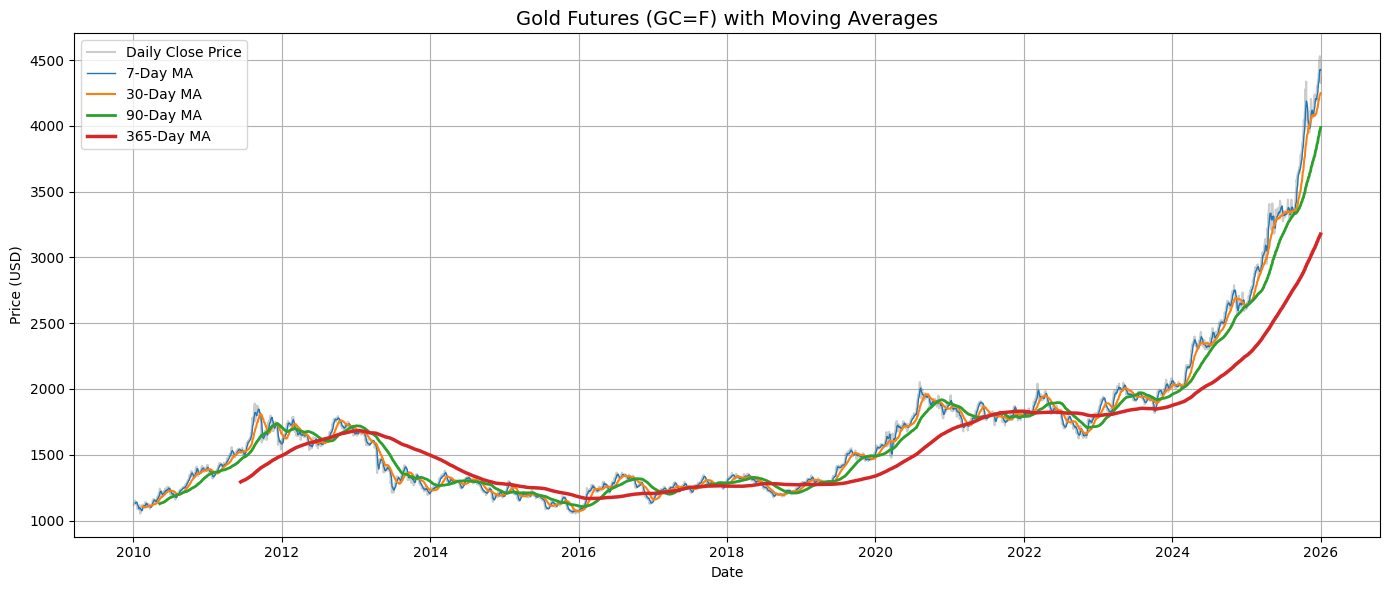

In [12]:
# Moving Averages using Close price
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_90'] = df['Close'].rolling(window=90).mean()
df['MA_365'] = df['Close'].rolling(window=365).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], alpha=0.4, label='Daily Close Price', color='gray')
ax.plot(df.index, df['MA_7'], label='7-Day MA', linewidth=1)
ax.plot(df.index, df['MA_30'], label='30-Day MA', linewidth=1.5)
ax.plot(df.index, df['MA_90'], label='90-Day MA', linewidth=2)
ax.plot(df.index, df['MA_365'], label='365-Day MA', linewidth=2.5)

ax.set_title('Gold Futures (GC=F) with Moving Averages', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()

plt.tight_layout()
plt.grid(True)
plt.show()

The moving average plot of Gold Futures (GC=F) from 2010 to 2025 shows a clear long-term upward trend, particularly accelerating after 2019 and sharply increasing during 2024–2025. The 7-day and 30-day moving averages closely track short-term fluctuations, while the 90-day and 365-day moving averages highlight the broader trend. The alignment of shorter moving averages above the longer ones in recent years indicates strong bullish momentum. Overall, the series exhibits a strong non-linear trend and volatility, suggesting non-stationarity and justifying the use of differencing or return-based modelling for forecasting.

Seasonal Decomposition of Gold Futures (GC=F)

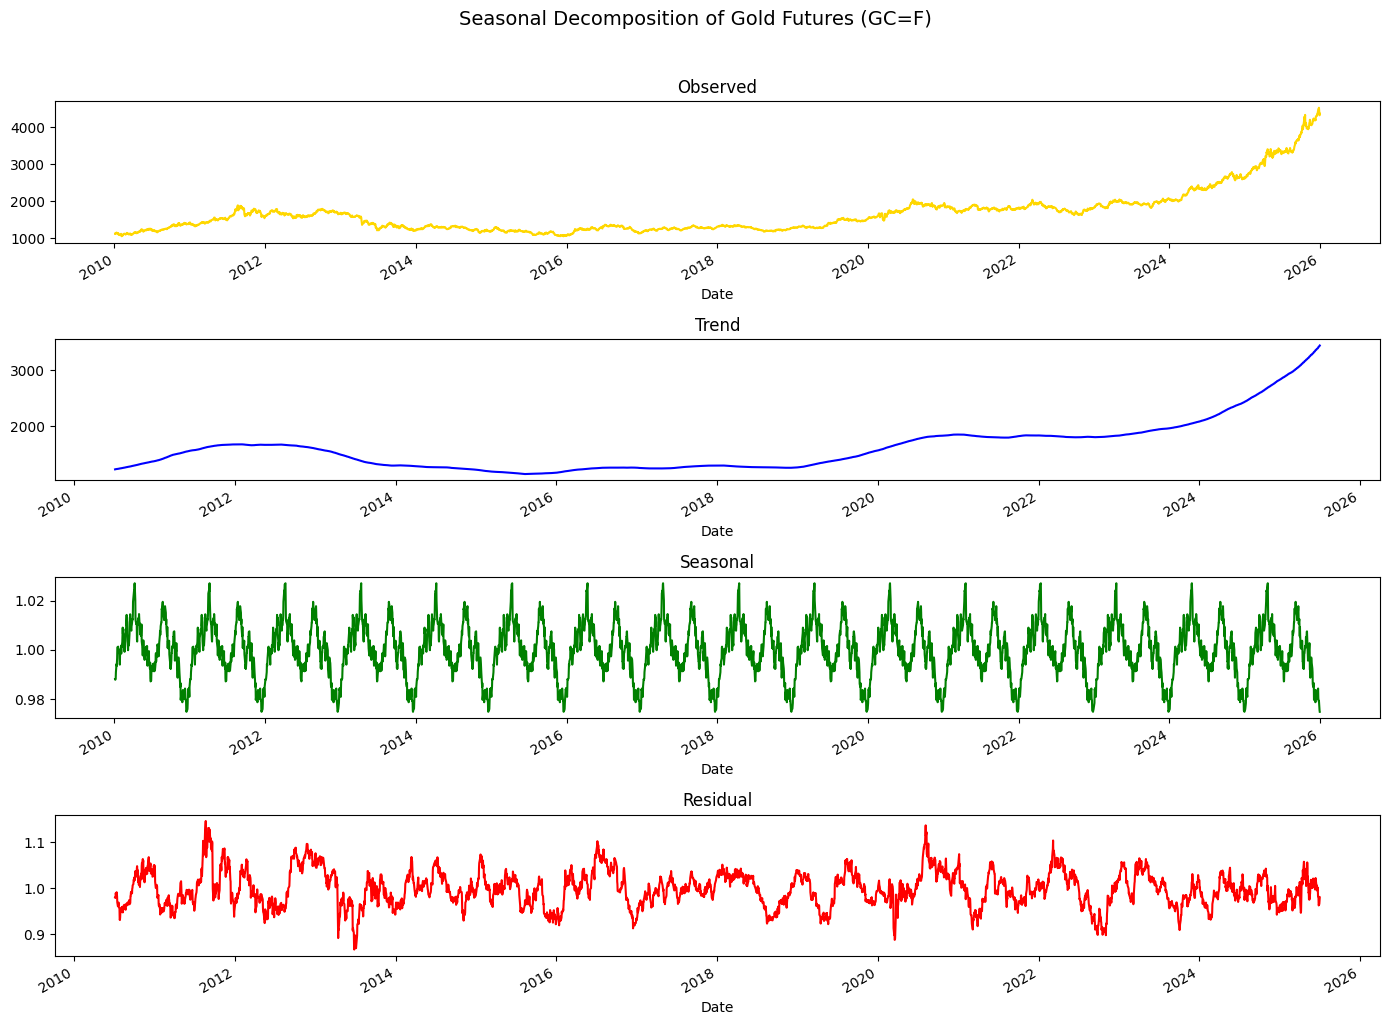

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal Decomposition using Close price
decomposition = seasonal_decompose(
    df['Close'].dropna(),
    model='multiplicative',
    period=252   # 252 trading days ≈ 1 year
)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], title='Observed', color='gold')
decomposition.trend.plot(ax=axes[1], title='Trend', color='blue')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')

plt.suptitle('Seasonal Decomposition of Gold Futures (GC=F)',
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

The seasonal decomposition of Gold Futures (GC=F) shows that the observed series is dominated by a strong upward long-term trend, particularly accelerating after 2019 and sharply rising toward 2025. The trend component clearly captures this sustained growth pattern. The seasonal component fluctuates within a narrow range around 1, indicating relatively weak but consistent yearly seasonality. The residual component reflects short-term irregular fluctuations and market shocks not explained by trend or seasonality. Overall, the decomposition confirms that gold prices are primarily trend-driven with limited seasonal influence, supporting the need for differencing or return-based modelling for accurate forecasting.

Stationarity Test (ADF Test)

In [15]:
from statsmodels.tsa.stattools import adfuller

# Stationarity Test on Close price
result = adfuller(df['Close'].dropna())

print('Augmented Dickey-Fuller Test:')
print(f'   ADF Statistic: {result[0]:.4f}')
print(f'   p-value: {result[1]:.4f}')
print(f'   Critical Values:')

for key, value in result[4].items():
    print(f'      {key}: {value:.4f}')

print(f'\n   Series is {"stationary" if result[1] < 0.05 else "non-stationary"}')

Augmented Dickey-Fuller Test:
   ADF Statistic: 5.0505
   p-value: 1.0000
   Critical Values:
      1%: -3.4320
      5%: -2.8623
      10%: -2.5672

   Series is non-stationary


Feature Engineering – Gold Futures

In [16]:
# Create Features using Close price
df['Daily_Return'] = df['Close'].pct_change() * 100

df['Volatility_7d'] = df['Daily_Return'].rolling(7).std()
df['Volatility_30d'] = df['Daily_Return'].rolling(30).std()

df['Price_Range'] = df['High'] - df['Low']

df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek
df['Quarter'] = df.index.quarter


# Lag Features
for lag in [1, 7, 14, 30]:
    df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)


print('Feature Engineering Complete!')
print(f'Total Features: {len(df.columns)}')
df.head()

Feature Engineering Complete!
Total Features: 21


,Close,High,Low,Open,Volume,Year,MA_7,MA_30,MA_90,MA_365,...,Volatility_7d,Volatility_30d,Price_Range,Month,DayOfWeek,Quarter,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,25.200073,1,0,1,NaN,NaN,NaN,NaN
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,11.500000,1,1,1,1117.699951,NaN,NaN,NaN
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,18.500000,1,2,1,1118.099976,NaN,NaN,NaN
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,3.900024,1,3,1,1135.900024,NaN,NaN,NaN
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,2010,NaN,NaN,NaN,NaN,...,NaN,NaN,15.500000,1,4,1,1133.099976,NaN,NaN,NaN


Correlation Heatmap – Gold Futures

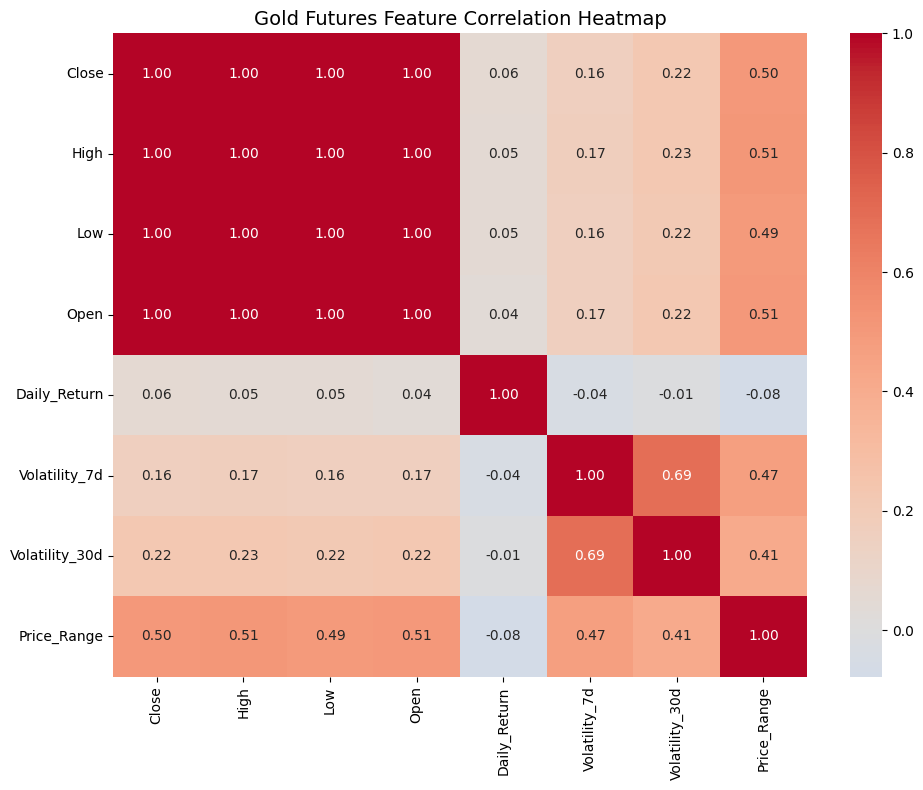

In [42]:
import seaborn as sns

# Select relevant columns
corr_cols = ['Close', 'High', 'Low', 'Open',
             'Daily_Return', 'Volatility_7d', 'Volatility_30d',
             'Price_Range']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    ax=ax
)

ax.set_title('Gold Futures Feature Correlation Heatmap',
             fontsize=14)

plt.tight_layout()
plt.show()

The correlation heatmap shows that the core price variables (Close, Open, High, and Low) are almost perfectly positively correlated (≈1.00), indicating strong multicollinearity since they represent similar price information. Daily_Return has very weak correlation with price levels, confirming that returns are largely independent of absolute price values. Volatility_7d and Volatility_30d exhibit a strong positive correlation (≈0.69), as both measure rolling risk over different windows. Price_Range shows moderate positive correlation with price levels and volatility, suggesting that larger daily movements are associated with higher market volatility. Overall, the heatmap highlights redundancy among price variables and supports the use of engineered features such as returns and volatility for predictive modelling.

Random Forest Regressor Model

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


features = [
    'Close_Lag_1',
    'Close_Lag_7',
    'Close_Lag_14',
    'Close_Lag_30',
    'Volatility_7d',
    'Volatility_30d',
    'Price_Range',
    'Month',
    'DayOfWeek',
    'Quarter'
]

X = df[features]
y = df['Close']


In [38]:
# Time-based Train-Test Split (80/20)
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [39]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)


# Predictions
y_pred = rf_model.predict(X_test)

In [40]:
# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Random Forest Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)


Random Forest Results
RMSE: 937.9214189254844
MAE: 641.2162082954026
R2: -0.7954665641893748
MAPE: 19.836018266575042


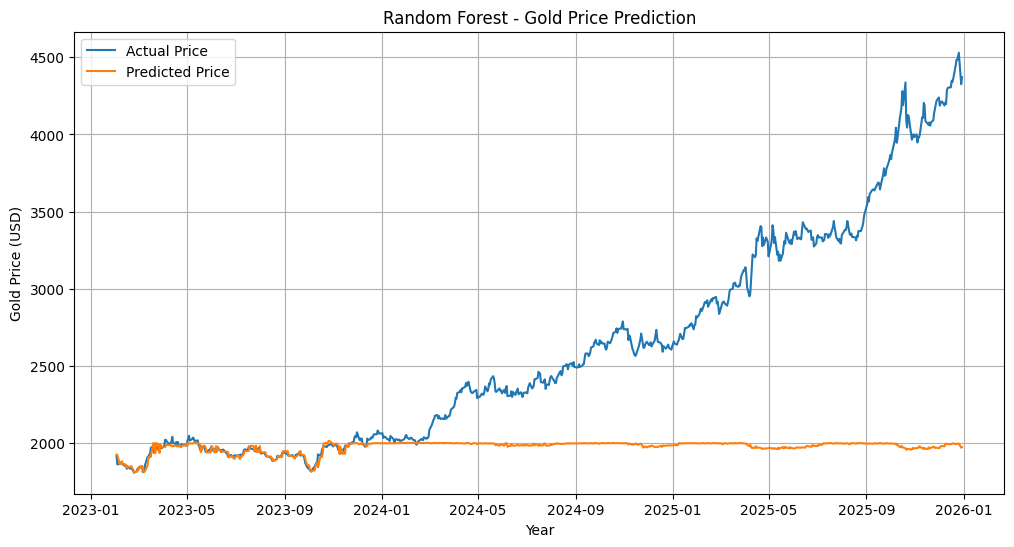

In [41]:
# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual Price")
plt.plot(y_test.index, y_pred, label="Predicted Price")
plt.title("Random Forest - Gold Price Prediction")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

The Random Forest model performed poorly in predicting gold closing prices, as indicated by the negative R² value (-0.79) and high RMSE and MAPE. The predicted values remain nearly flat around the historical average, while the actual gold prices show a strong upward trend, especially during 2024–2025. This failure occurs because Random Forest is a tree-based model that performs well at interpolation within the training range but struggles with extrapolation beyond previously observed values. Since gold prices experienced a sharp structural increase in the test period, the model was unable to generalise this new trend and instead predicted values close to earlier historical levels.

Furthermore, financial time series such as gold prices are highly non-linear, non-stationary, and influenced by macroeconomic shocks, which makes direct price-level prediction challenging for traditional machine learning models. Although lag and volatility features were included, the strong upward trend dominated the series, and Random Forest could not inherently model temporal dynamics in the same way as time-series-specific methods. This demonstrates that tree-based models are not well-suited for forecasting trending financial price levels